# 🧠 Prediksi Depresi pada Mahasiswa
**Mata Kuliah:** Kecerdasan Buatan  
**Metode:** Machine Learning — Random Forest Classifier  
**Dataset:** Depression Student Dataset (502 data, 11 kolom)  

---
## 📌 Tujuan
Membangun model Machine Learning untuk memprediksi apakah seorang mahasiswa mengalami **depresi (Yes/No)** berdasarkan faktor akademik, gaya hidup, dan riwayat kesehatan mental.

## 1️⃣ Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

print('✅ Semua library berhasil di-import!')

✅ Semua library berhasil di-import!


## 2️⃣ Load Dataset

In [2]:
# Pastikan file 'Depression Student Dataset.csv' sudah diupload ke Colab
df = pd.read_csv('Depression Student Dataset.csv')

print('✅ Dataset berhasil dimuat!')
print(f'📊 Jumlah data : {df.shape[0]} baris')
print(f'📋 Jumlah kolom: {df.shape[1]} kolom')
print(f'\n📋 Nama kolom:')
for col in df.columns:
    print(f'   - {col}')

✅ Dataset berhasil dimuat!
📊 Jumlah data : 502 baris
📋 Jumlah kolom: 11 kolom

📋 Nama kolom:
   - Gender
   - Age
   - Academic Pressure
   - Study Satisfaction
   - Sleep Duration
   - Dietary Habits
   - Have you ever had suicidal thoughts ?
   - Study Hours
   - Financial Stress
   - Family History of Mental Illness
   - Depression


In [3]:
# Tampilkan 5 baris pertama
df.head()

,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,28,2.0,4.0,7-8 hours,Moderate,Yes,9,2,Yes,No
1,Male,28,4.0,5.0,5-6 hours,Healthy,Yes,7,1,Yes,No
2,Male,25,1.0,3.0,5-6 hours,Unhealthy,Yes,10,4,No,Yes
3,Male,23,1.0,4.0,More than 8 hours,Unhealthy,Yes,7,2,Yes,No
4,Female,31,1.0,5.0,More than 8 hours,Healthy,Yes,4,2,Yes,No


In [4]:
# Info tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 502 non-null    object 
 1   Age                                    502 non-null    int64  
 2   Academic Pressure                      502 non-null    float64
 3   Study Satisfaction                     502 non-null    float64
 4   Sleep Duration                         502 non-null    object 
 5   Dietary Habits                         502 non-null    object 
 6   Have you ever had suicidal thoughts ?  502 non-null    object 
 7   Study Hours                            502 non-null    int64  
 8   Financial Stress                       502 non-null    int64  
 9   Family History of Mental Illness       502 non-null    object 
 10  Depression                             502 non-null    object 
dtypes: flo

In [5]:
# Statistik deskriptif
df.describe(include='all')

,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
count,502,502.000000,502.000000,502.000000,502,502,502,502.000000,502.000000,502,502
unique,2,NaN,NaN,NaN,4,3,2,NaN,NaN,2,2
top,Male,NaN,NaN,NaN,7-8 hours,Moderate,Yes,NaN,NaN,No,Yes
freq,267,NaN,NaN,NaN,128,172,260,NaN,NaN,265,252
mean,NaN,26.241036,3.003984,3.075697,NaN,NaN,NaN,6.404382,2.928287,NaN,NaN
std,NaN,4.896501,1.390007,1.373490,NaN,NaN,NaN,3.742434,1.425053,NaN,NaN
min,NaN,18.000000,1.000000,1.000000,NaN,NaN,NaN,0.000000,1.000000,NaN,NaN
25%,NaN,22.000000,2.000000,2.000000,NaN,NaN,NaN,3.000000,2.000000,NaN,NaN
50%,NaN,26.500000,3.000000,3.000000,NaN,NaN,NaN,7.000000,3.000000,NaN,NaN
75%,NaN,30.000000,4.000000,4.000000,NaN,NaN,NaN,10.000000,4.000000,NaN,NaN


## 3️⃣ Exploratory Data Analysis (EDA)

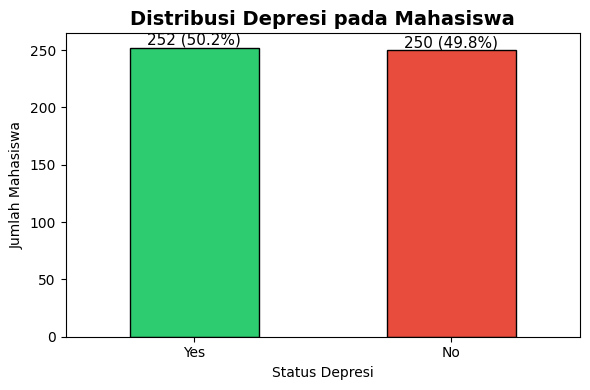

Depression
Yes    252
No     250
Name: count, dtype: int64


In [6]:
# Distribusi target Depression (Yes/No)
plt.figure(figsize=(6, 4))
counts = df['Depression'].value_counts()
colors = ['#2ecc71', '#e74c3c']
ax = counts.plot(kind='bar', color=colors, edgecolor='black', width=0.5)
plt.title('Distribusi Depresi pada Mahasiswa', fontsize=14, fontweight='bold')
plt.xlabel('Status Depresi')
plt.ylabel('Jumlah Mahasiswa')
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({int(p.get_height())/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('distribusi_kelas.png', dpi=150, bbox_inches='tight')
plt.show()
print(counts)

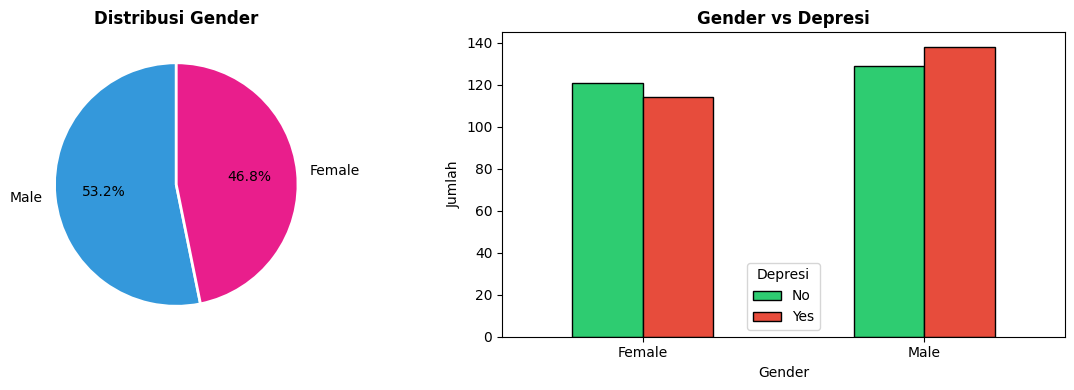

In [7]:
# Distribusi Gender vs Depression
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gender distribution
df['Gender'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.1f%%',
                                  colors=['#3498db', '#e91e8c'],
                                  startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Distribusi Gender', fontweight='bold')
axes[0].set_ylabel('')

# Gender vs Depression
ct = pd.crosstab(df['Gender'], df['Depression'])
ct.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('Gender vs Depresi', fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Jumlah')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Depresi')

plt.tight_layout()
plt.savefig('gender_vs_depresi.png', dpi=150, bbox_inches='tight')
plt.show()

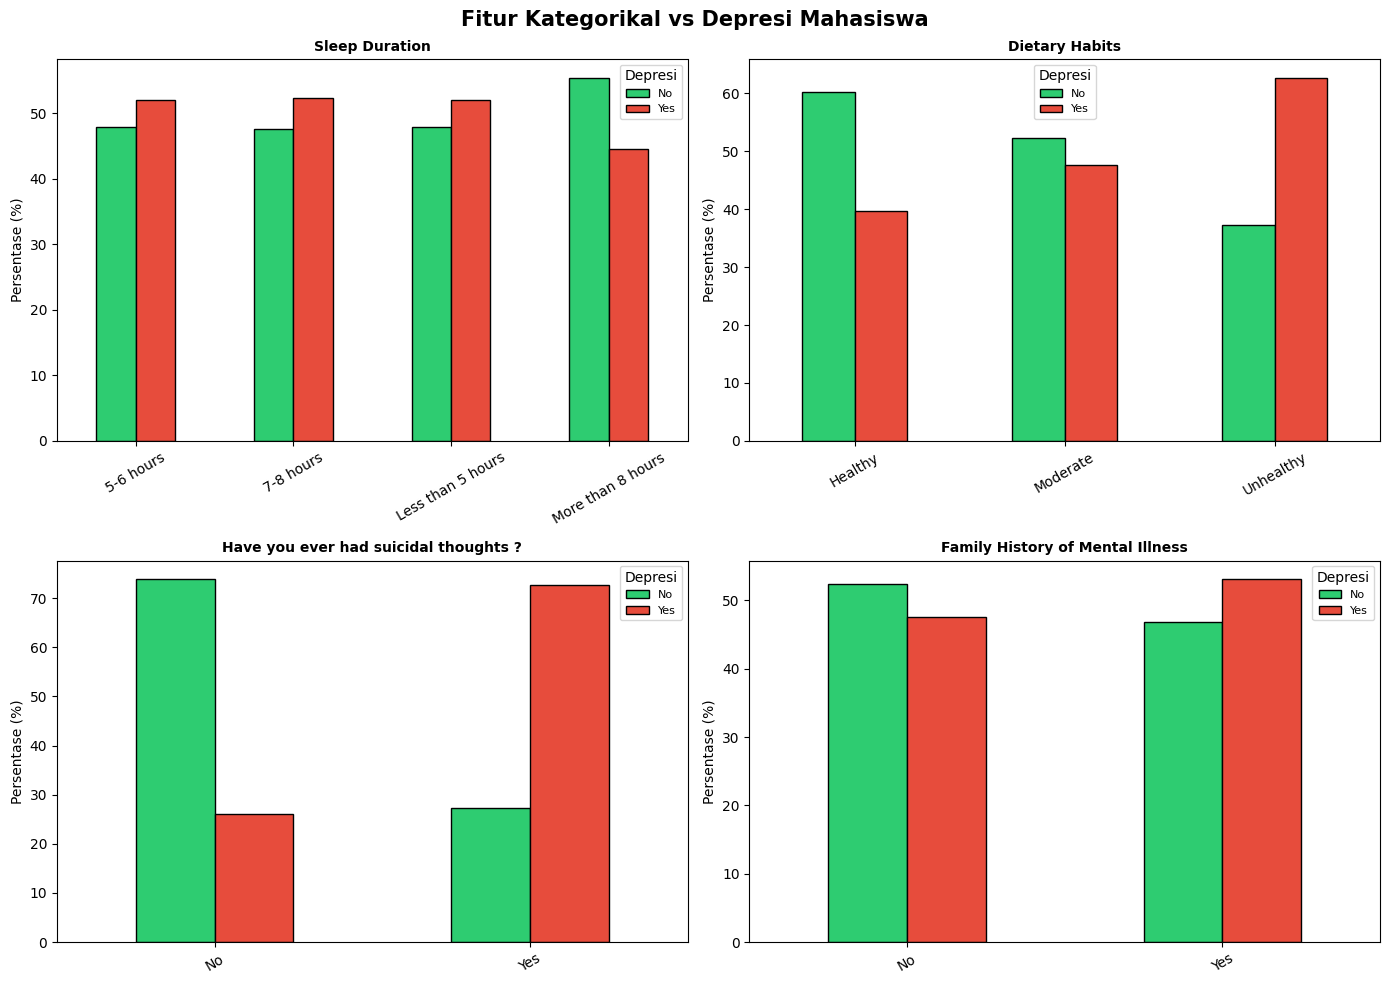

In [8]:
# Visualisasi fitur kategorikal vs Depression
cat_features = ['Sleep Duration', 'Dietary Habits',
                'Have you ever had suicidal thoughts ?',
                'Family History of Mental Illness']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Fitur Kategorikal vs Depresi Mahasiswa', fontsize=15, fontweight='bold')

for ax, feat in zip(axes.flatten(), cat_features):
    ct = pd.crosstab(df[feat], df['Depression'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='black')
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_ylabel('Persentase (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Depresi', fontsize=8)

plt.tight_layout()
plt.savefig('analisis_fitur_kategorikal.png', dpi=150, bbox_inches='tight')
plt.show()

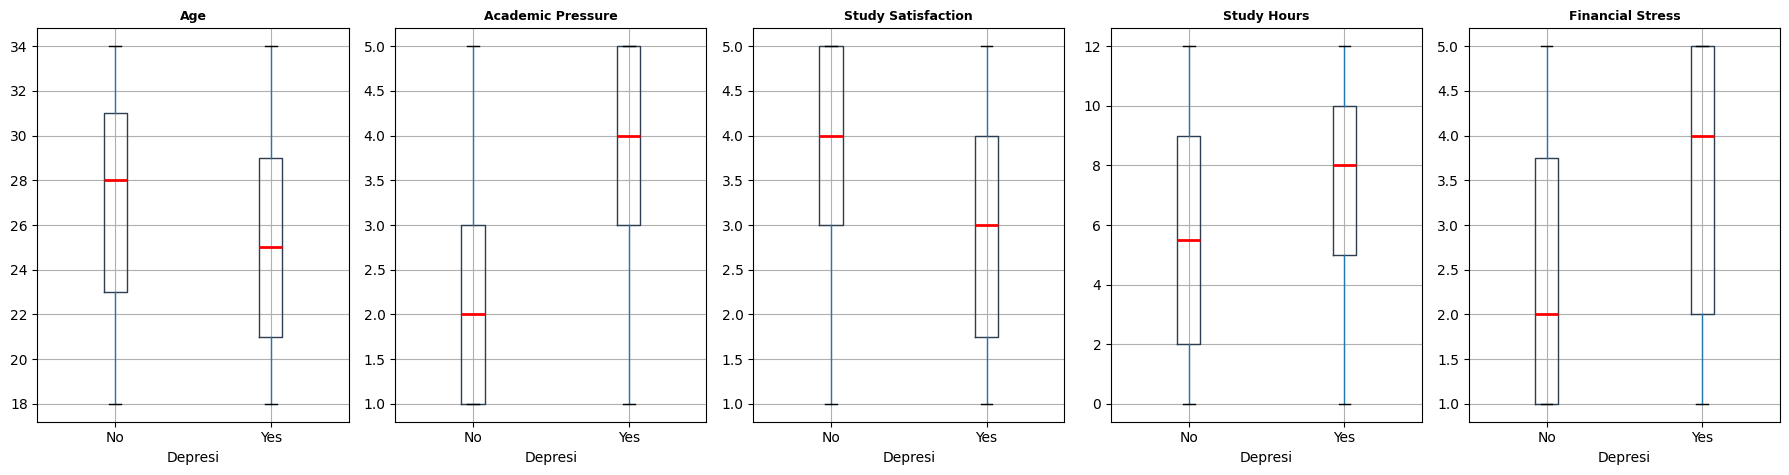

In [9]:
# Visualisasi fitur numerik vs Depression
num_features = ['Age', 'Academic Pressure', 'Study Satisfaction',
                'Study Hours', 'Financial Stress']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Fitur Numerik vs Depresi Mahasiswa', fontsize=13, fontweight='bold')

for ax, feat in zip(axes, num_features):
    df.boxplot(column=feat, by='Depression', ax=ax,
               boxprops=dict(color='#2c3e50'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='gray', markersize=4))
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_xlabel('Depresi')

plt.suptitle('')
plt.tight_layout()
plt.savefig('analisis_fitur_numerik.png', dpi=150, bbox_inches='tight')
plt.show()

## 4️⃣ Preprocessing Data

In [10]:
# Cek missing values
print('🔍 Cek Missing Values:')
missing = df.isnull().sum()
if missing.sum() == 0:
    print('✅ Tidak ada missing values!')
else:
    print(missing[missing > 0])
    # Handle missing values
    for col in df.select_dtypes(include=[np.number]).columns:
        df[col].fillna(df[col].median(), inplace=True)
    for col in df.select_dtypes(include=['object']).columns:
        df[col].fillna(df[col].mode()[0], inplace=True)
    print('✅ Missing values berhasil ditangani!')

🔍 Cek Missing Values:
✅ Tidak ada missing values!


In [11]:
# Cek duplikat
dup = df.duplicated().sum()
print(f'🔍 Data duplikat: {dup}')
if dup > 0:
    df.drop_duplicates(inplace=True)
    print(f'✅ Duplikat dihapus. Sisa data: {len(df)}')
else:
    print('✅ Tidak ada duplikat!')

🔍 Data duplikat: 0
✅ Tidak ada duplikat!


In [12]:
# Label Encoding semua kolom kategorikal
# Kolom kategorikal di dataset ini:
# Gender, Sleep Duration, Dietary Habits,
# Have you ever had suicidal thoughts ?,
# Family History of Mental Illness, Depression

df_encoded = df.copy()
le = LabelEncoder()

cat_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()
print('🔄 Label Encoding kolom kategorikal:')
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f'   ✅ {col} → {dict(zip(le.classes_, le.transform(le.classes_)))}')

print('\n✅ Encoding selesai!')
df_encoded.head()

🔄 Label Encoding kolom kategorikal:
   ✅ Gender → {'Female': np.int64(0), 'Male': np.int64(1)}
   ✅ Sleep Duration → {'5-6 hours': np.int64(0), '7-8 hours': np.int64(1), 'Less than 5 hours': np.int64(2), 'More than 8 hours': np.int64(3)}
   ✅ Dietary Habits → {'Healthy': np.int64(0), 'Moderate': np.int64(1), 'Unhealthy': np.int64(2)}
   ✅ Have you ever had suicidal thoughts ? → {'No': np.int64(0), 'Yes': np.int64(1)}
   ✅ Family History of Mental Illness → {'No': np.int64(0), 'Yes': np.int64(1)}
   ✅ Depression → {'No': np.int64(0), 'Yes': np.int64(1)}

✅ Encoding selesai!


,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1,28,2.0,4.0,1,1,1,9,2,1,0
1,1,28,4.0,5.0,0,0,1,7,1,1,0
2,1,25,1.0,3.0,0,2,1,10,4,0,1
3,1,23,1.0,4.0,3,2,1,7,2,1,0
4,0,31,1.0,5.0,3,0,1,4,2,1,0


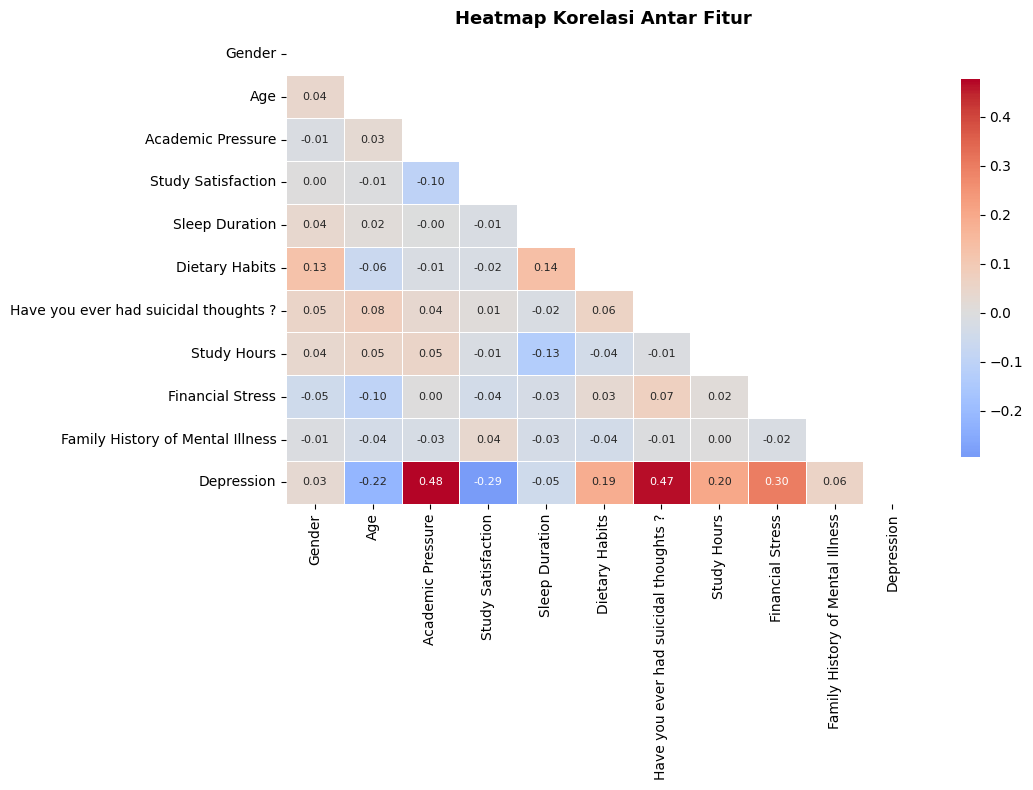

In [13]:
# Heatmap korelasi (setelah encoding)
plt.figure(figsize=(11, 8))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8}, annot_kws={'size': 8})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Pisahkan fitur (X) dan target (y)
X = df_encoded.drop('Depression', axis=1)
y = df_encoded['Depression']

print(f'📐 Fitur (X) : {X.shape[1]} kolom, {X.shape[0]} baris')
print(f'📐 Target (y): {y.shape[0]} baris')
print(f'\n📋 Fitur yang digunakan:')
for i, col in enumerate(X.columns, 1):
    print(f'   {i:2}. {col}')

📐 Fitur (X) : 10 kolom, 502 baris
📐 Target (y): 502 baris

📋 Fitur yang digunakan:
    1. Gender
    2. Age
    3. Academic Pressure
    4. Study Satisfaction
    5. Sleep Duration
    6. Dietary Habits
    7. Have you ever had suicidal thoughts ?
    8. Study Hours
    9. Financial Stress
   10. Family History of Mental Illness


In [15]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('✅ Data berhasil dibagi:')
print(f'   🏋️ Training : {X_train.shape[0]} data ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'   🧪 Testing  : {X_test.shape[0]} data ({X_test.shape[0]/len(df)*100:.1f}%)')

✅ Data berhasil dibagi:
   🏋️ Training : 401 data (79.9%)
   🧪 Testing  : 101 data (20.1%)


In [16]:
# StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('✅ Feature scaling selesai (StandardScaler)')

✅ Feature scaling selesai (StandardScaler)


## 5️⃣ Training Model — Random Forest

In [17]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print('🌳 Melatih model Random Forest...')
rf_model.fit(X_train_scaled, y_train)
print('✅ Model berhasil dilatih!')

🌳 Melatih model Random Forest...
✅ Model berhasil dilatih!


## 6️⃣ Evaluasi Model

In [18]:
y_pred       = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred_proba)

print('=' * 46)
print('   📊 HASIL EVALUASI MODEL RANDOM FOREST')
print('=' * 46)
print(f'   🎯 Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'   📈 ROC-AUC   : {roc:.4f}')
print('=' * 46)

   📊 HASIL EVALUASI MODEL RANDOM FOREST
   🎯 Accuracy  : 0.9307  (93.07%)
   📈 ROC-AUC   : 0.9816


In [19]:
print('📋 Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Tidak Depresi (No)', 'Depresi (Yes)']))

📋 Classification Report:
                    precision    recall  f1-score   support

Tidak Depresi (No)       0.96      0.90      0.93        50
     Depresi (Yes)       0.91      0.96      0.93        51

          accuracy                           0.93       101
         macro avg       0.93      0.93      0.93       101
      weighted avg       0.93      0.93      0.93       101



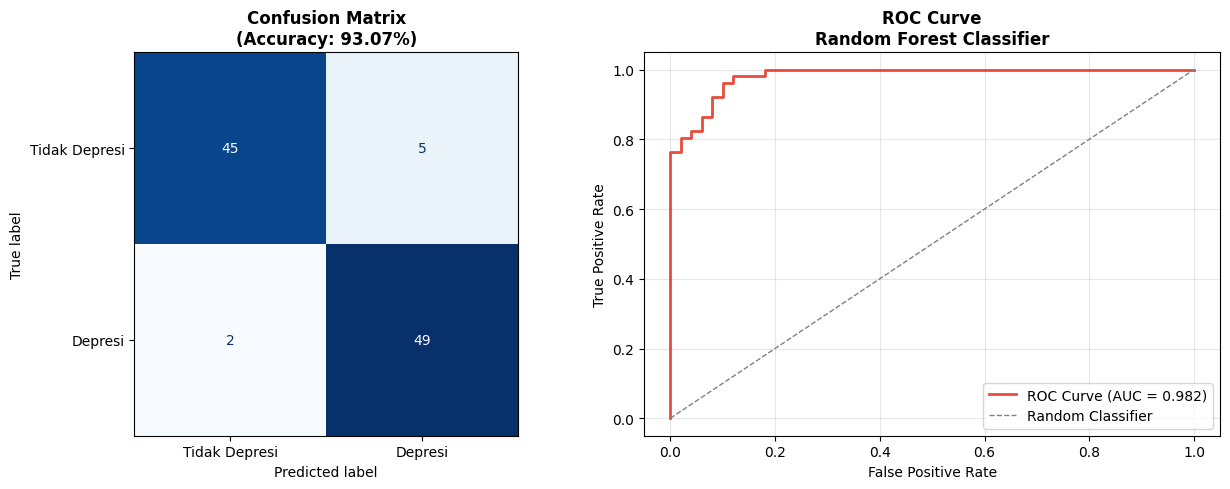

✅ Confusion Matrix & ROC Curve tersimpan!


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Tidak Depresi', 'Depresi'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix\n(Accuracy: {acc*100:.2f}%)', fontsize=12, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC Curve (AUC = {roc:.3f})')
axes[1].plot([0, 1], [0, 1], 'gray', lw=1, linestyle='--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve\nRandom Forest Classifier', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('confusion_matrix_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion Matrix & ROC Curve tersimpan!')

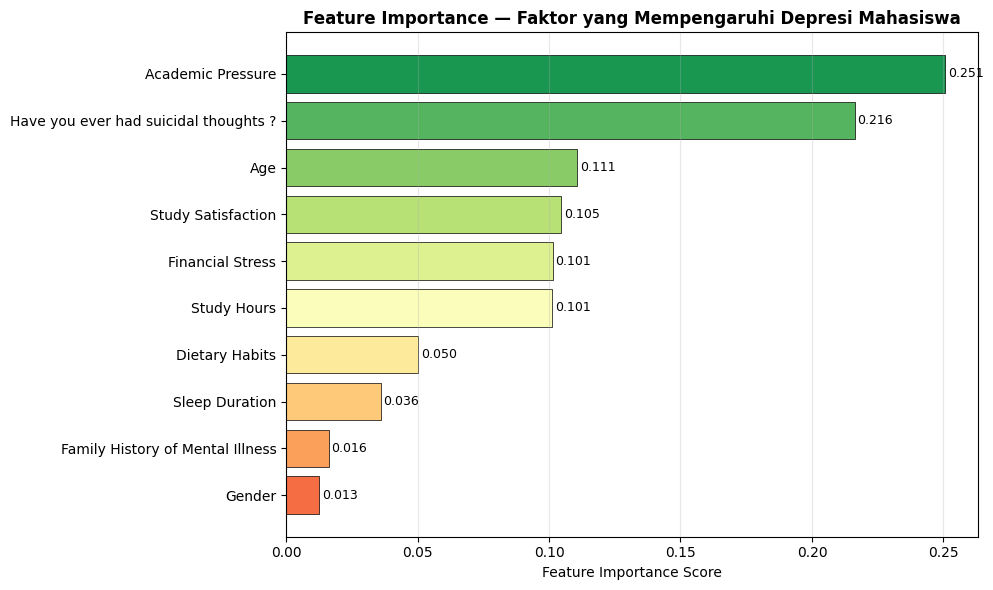


🏆 Top 5 Fitur Paling Berpengaruh:
                                Fitur  Importance
                    Academic Pressure    0.250697
Have you ever had suicidal thoughts ?    0.216328
                                  Age    0.110752
                   Study Satisfaction    0.104573
                     Financial Stress    0.101348


In [21]:
# Feature Importance
importance_df = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importance_df)))
bars = plt.barh(importance_df['Fitur'], importance_df['Importance'],
                color=colors, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, importance_df['Importance']):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.xlabel('Feature Importance Score')
plt.title('Feature Importance — Faktor yang Mempengaruhi Depresi Mahasiswa',
          fontsize=12, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n🏆 Top 5 Fitur Paling Berpengaruh:')
print(importance_df.tail(5)[['Fitur','Importance']].iloc[::-1].to_string(index=False))

🔄 Menjalankan 5-Fold Cross Validation...

📊 Hasil Cross Validation:
   Skor tiap fold : ['0.8642', '0.8750', '0.8500', '0.9250', '0.9250']
   Mean Accuracy  : 0.8878 (88.78%)
   Std Deviation  : ± 0.0314


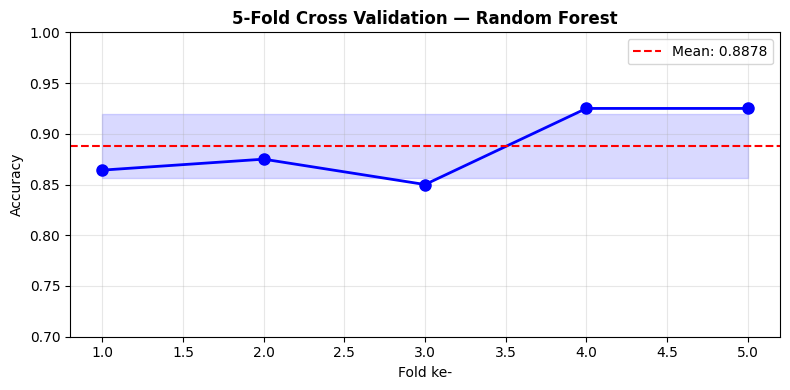

In [22]:
# 5-Fold Cross Validation
print('🔄 Menjalankan 5-Fold Cross Validation...')
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print(f'\n📊 Hasil Cross Validation:')
print(f'   Skor tiap fold : {[f"{s:.4f}" for s in cv_scores]}')
print(f'   Mean Accuracy  : {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)')
print(f'   Std Deviation  : ± {cv_scores.std():.4f}')

plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), cv_scores, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=cv_scores.mean(), color='r', linestyle='--',
            label=f'Mean: {cv_scores.mean():.4f}')
plt.fill_between(range(1, 6),
                 cv_scores.mean() - cv_scores.std(),
                 cv_scores.mean() + cv_scores.std(),
                 alpha=0.15, color='blue')
plt.xlabel('Fold ke-')
plt.ylabel('Accuracy')
plt.title('5-Fold Cross Validation — Random Forest', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.7, 1.0)
plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7️⃣ Demo Prediksi — Input Manual

In [30]:
# ============================================================
# 🎮 DEMO: Ubah nilai di bawah ini untuk memprediksi mahasiswa baru
# ============================================================

# Encoding referensi:
# Gender              : Female=0, Male=1
# Sleep Duration      : '5-6 hours'=0, '7-8 hours'=1, 'Less than 5 hours'=2, 'More than 8 hours'=3
# Dietary Habits      : 'Healthy'=0, 'Moderate'=1, 'Unhealthy'=2
# Suicidal thoughts   : 'No'=0, 'Yes'=1
# Family History      : 'No'=0, 'Yes'=1

sample = {
    'Gender'                                : 0,   # 1=Male, 0=Female
    'Age'                                   : 19,  # usia
    'Academic Pressure'                     : 4,   # skala 1-5
    'Study Satisfaction'                    : 2,   # skala 1-5
    'Sleep Duration'                        : 4,   # 2=Less than 5 hours
    'Dietary Habits'                        : 3,   # 2=Unhealthy
    'Have you ever had suicidal thoughts ?' : 0,   # 1=Yes
    'Study Hours'                           : 3,   # jam per hari
    'Financial Stress'                      : 1,   # skala 1-5
    'Family History of Mental Illness'      : 0,   # 1=Yes
}

sample_df     = pd.DataFrame([sample])
sample_scaled = scaler.transform(sample_df)
pred          = rf_model.predict(sample_scaled)
proba         = rf_model.predict_proba(sample_scaled)[0]

print('=' * 46)
print('         🎯 HASIL PREDIKSI DEMO')
print('=' * 46)
status = '😢 DEPRESI (Yes)' if pred[0] == 1 else '😊 TIDAK DEPRESI (No)'
print(f'   Status Prediksi           : {status}')
print(f'   Probabilitas Tidak Depresi: {proba[0]*100:.2f}%')
print(f'   Probabilitas Depresi      : {proba[1]*100:.2f}%')
print('=' * 46)
print()
print('💡 Coba ubah nilai-nilai di atas untuk memprediksi profil mahasiswa yang berbeda!')

         🎯 HASIL PREDIKSI DEMO
   Status Prediksi           : 😢 DEPRESI (Yes)
   Probabilitas Tidak Depresi: 49.27%
   Probabilitas Depresi      : 50.73%

💡 Coba ubah nilai-nilai di atas untuk memprediksi profil mahasiswa yang berbeda!


## 8️⃣ Ringkasan Hasil

In [24]:
print('=' * 50)
print('         📊 RINGKASAN PROYEK')
print('=' * 50)
print(f'   Proyek    : Prediksi Depresi pada Mahasiswa')
print(f'   Algoritma : Random Forest Classifier')
print(f'   Dataset   : {len(df)} data, {len(X.columns)} fitur')
print(f'   Train/Test: 80% / 20%')
print(f'   Accuracy  : {acc*100:.2f}%')
print(f'   ROC-AUC   : {roc:.4f}')
print(f'   CV Score  : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')
print('=' * 50)
print()
print('📁 File gambar yang dihasilkan:')
files = [
    'distribusi_kelas.png',
    'gender_vs_depresi.png',
    'analisis_fitur_kategorikal.png',
    'analisis_fitur_numerik.png',
    'heatmap_korelasi.png',
    'confusion_matrix_roc.png',
    'feature_importance.png',
    'cross_validation.png'
]
for f in files:
    print(f'   ✅ {f}')

         📊 RINGKASAN PROYEK
   Proyek    : Prediksi Depresi pada Mahasiswa
   Algoritma : Random Forest Classifier
   Dataset   : 502 data, 10 fitur
   Train/Test: 80% / 20%
   Accuracy  : 93.07%
   ROC-AUC   : 0.9816
   CV Score  : 88.78% ± 3.14%

📁 File gambar yang dihasilkan:
   ✅ distribusi_kelas.png
   ✅ gender_vs_depresi.png
   ✅ analisis_fitur_kategorikal.png
   ✅ analisis_fitur_numerik.png
   ✅ heatmap_korelasi.png
   ✅ confusion_matrix_roc.png
   ✅ feature_importance.png
   ✅ cross_validation.png
